## 0. Global Imports

### Description de l'étape

Cette première cellule regroupe l'ensemble des bibliothèques nécessaires au notebook. Il s'agit d'une pratique essentielle en développement data science pour plusieurs raisons :

- **Centralisation** : tous les imports au même endroit facilitent la maintenance et la compréhension du notebook.
- **Reproductibilité** : un lecteur peut vérifier d'emblée toutes les dépendances requises.
- **Prévention des erreurs** : les imports tardifs (dans des cellules au milieu du notebook) créent des états incohérents lors de relances partielles.

Les bibliothèques chargées couvrent cinq domaines :
1. **Manipulation de données** : `pandas`, `numpy`
2. **Visualisation** : `matplotlib`, `seaborn`, `plotly`
3. **NLP** : `nltk` (stopwords, lemmatisation, stemming), `sklearn.TfidfVectorizer`
4. **Données manquantes** : `missingno`
5. **Utilitaires** : `re`, `collections.Counter`, `pathlib`

In [175]:
import os
import sys
from pathlib import Path

# Must be set before any src.* import
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
from collections import Counter
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",  quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer


from src.data.make_dataset import load_data

pd.set_option("display.max_columns", None)
%matplotlib inline

### Analyse & Interprétation

L'exécution de cette cellule confirme que l'environnement est opérationnel. Les téléchargements NLTK (`stopwords`, `wordnet`, `omw-1.4`) s'effectuent silencieusement (`quiet=True`), ce qui garantit un comportement reproductible même lors d'une première installation.

**Points clés :**
- L'option `%matplotlib inline` active le rendu des graphiques Matplotlib directement dans le notebook.
- `pd.set_option("display.max_columns", None)` permet d'afficher l'intégralité des colonnes lors des aperçus de DataFrames, évitant les troncatures trompeuses.
- L'injection de `PROJECT_ROOT` dans `sys.path` rend les modules `src.*` importables depuis le notebook, conformément à l'architecture du projet.

Aucune erreur à ce stade indique que toutes les dépendances sont correctement installées et compatibles.

## 1. Global Configuration

### Description de l'étape

La configuration globale définit les chemins vers les répertoires de données et de modèles. Cette étape est fondamentale pour plusieurs raisons :

- **Portabilité** : en utilisant `pathlib.Path` et en construisant les chemins relativement à `PROJECT_ROOT`, le notebook fonctionne sur n'importe quel environnement (local, cloud, CI/CD) sans modification.
- **Séparation des préoccupations** : centraliser les chemins évite les chemins codés en dur dispersés dans le code.
- **Traçabilité** : l'affichage explicite des chemins résolus permet de détecter immédiatement toute erreur de configuration.

Cette approche est cohérente avec les règles du projet (`CLAUDE.md`) : *"No hardcoded paths — use `settings/config.yaml`"*.

In [176]:
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR_INPUT = DATA_DIR / "raw"
DATA_DIR_PROCESSED = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

print(f"PROJECT_ROOT     : {PROJECT_ROOT}")
print(f"DATA_DIR         : {DATA_DIR}")
print(f"DATA_DIR_INPUT   : {DATA_DIR_INPUT}")
print(f"MODEL_DIR        : {MODEL_DIR}")

PROJECT_ROOT     : C:\Users\BachirTraore\Desktop\tps\NLP_Disaster_Tweets-
DATA_DIR         : C:\Users\BachirTraore\Desktop\tps\NLP_Disaster_Tweets-\data
DATA_DIR_INPUT   : C:\Users\BachirTraore\Desktop\tps\NLP_Disaster_Tweets-\data\raw
MODEL_DIR        : C:\Users\BachirTraore\Desktop\tps\NLP_Disaster_Tweets-\models


### Analyse & Interprétation

Les chemins sont correctement résolus .

**Observations importantes :**
- `PROJECT_ROOT` pointe vers la racine du projet, deux niveaux au-dessus du notebook (`notebooks/`), ce qui est la convention MLOps standard.
- Les sous-répertoires `data/raw/`, `data/processed/` et `models/` suivent la structure Cookie Cutter Data Science, garantissant une organisation claire des artefacts.
- Aucune erreur de chemin manquant n'est levée, ce qui confirme que l'arborescence du projet est correctement initialisée.

## 2. Load Data

### Description de l'étape

Le chargement des données est le point d'entrée de tout pipeline ML. Cette étape utilise une fonction centralisée `load_data()` issue de `src/data/make_dataset.py`, conformément au principe d'architecture du projet : **aucune manipulation de données brutes directement dans le notebook**.

**Importance de cette étape :**
- **Abstraction** : la logique de chargement (gestion des chemins, formats, encodages) est encapsulée dans `src/`, rendant le notebook lisible et stable.
- **Traçabilité** : le logger (Loguru) enregistre automatiquement la forme, les types et la description du dataset.
- **Flexibilité** : le paramètre `columns_to_lower=True` normalise les noms de colonnes dès le chargement, évitant des erreurs de casse ultérieures.
- **Source des données** : ce dataset provient d'OpenML et agrège des tweets collectés le 14 janvier 2020 autour de mots-clés liés aux catastrophes naturelles et événements médiatiques majeurs.

In [177]:
data = load_data(dataset_name="disaster-tweets", columns_to_lower=True)

2026-05-25 15:23:28 | INFO | src.data.make_dataset | Loaded 'disaster-tweets' dataset
2026-05-25 15:23:28 | INFO | src.data.make_dataset | Dataset description: Context
The file contains over 11,000 tweets associated with disaster keywords like crash, quarantine, and bush fires as well as the location and keyword itself. The data structure was inherited from Disasters on social media
The tweets were collected on Jan 14th, 2020.
Some of the topics people were tweeting:

The eruption of Taal Volcano in Batangas, Philippines
Coronavirus
Bushfires in Australia
Iran downing of the airplane flight PS752

Disclaimer: The dataset contains text that may be considered profane, vulgar, or offensive.
Inspiration
The intention was to enrich the already available data for this topic with newly collected and manually classified tweets.
The initial source Disasters on social media which is used in Real or Not? NLP with Disaster Tweets competition on Kaggle.

Downloaded from openml.org.
2026-05-25 15:23

### Analyse & Interprétation

Le chargement confirme les caractéristiques fondamentales du dataset :

| Propriété | Valeur |
|-----------|--------|
| Nombre de tweets | 11 370 |
| Nombre de colonnes | 5 (`id`, `keyword`, `location`, `text`, `target`) |
| Type de la cible | `bool` (binaire) |
| Type du texte | `string[python]` (pandas StringDtype) |

**Observations clés :**
- La colonne `keyword` contient **219 mots-clés uniques** — une dimension catégorielle potentiellement informative pour la prédiction.
- La colonne `location` présente déjà des valeurs manquantes (`7835 / 11370` non-nulles), soit ~31% de valeurs absentes.
- L'utilisation de `string[python]` (pandas nullable string) plutôt que `object` garantit une gestion explicite des `<NA>`, évitant les confusions avec les chaînes vides.
- La cible est de type `bool` : `True` = tweet de catastrophe réelle, `False` = non-catastrophe.

Ce dataset est raisonnablement propre dès le chargement, mais une analyse approfondie des valeurs manquantes et de la distribution des classes est indispensable avant toute modélisation.

## 3. Dataset overview

### Description de l'étape

L'aperçu général du dataset constitue la première étape exploratoire. Elle vise à répondre à trois questions fondamentales :

1. **Structure** : combien de lignes/colonnes ? Quels types de données ?
2. **Contenu** : à quoi ressemblent les premières observations ?
3. **Statistiques descriptives** : quelles sont les distributions, les valeurs uniques, les fréquences ?

Cette étape est indispensable car elle révèle les **problèmes potentiels** (types incorrects, colonnes inutilisables, déséquilibres) avant d'investir du temps en feature engineering ou en modélisation. Elle guide également le choix des transformations à appliquer.

In [178]:
data.head()

,id,keyword,location,text,target
0,0,ablaze,<NA>,"Communal violence in Bhainsa, Telangana. ""Ston...",True
1,1,ablaze,<NA>,Telangana: Section 144 has been imposed in Bha...,True
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,True
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,True
4,4,ablaze,<NA>,"""Lord Jesus, your love brings freedom and pard...",False


In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  string
 2   location  7835 non-null   string
 3   text      11370 non-null  string
 4   target    11370 non-null  bool  
dtypes: bool(1), int64(1), string(3)
memory usage: 366.5 KB


In [180]:
data.describe(include="all")

,id,keyword,location,text,target
count,11370.000000,11370,7835,11370,11370
unique,NaN,219,4358,11220,2
top,NaN,thunderstorm,United States,I want to help you with my project to save the...,False
freq,NaN,93,97,3,9256
mean,5684.500000,NaN,NaN,NaN,NaN
std,3282.380615,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,2842.250000,NaN,NaN,NaN,NaN
50%,5684.500000,NaN,NaN,NaN,NaN
75%,8526.750000,NaN,NaN,NaN,NaN


### Analyse & Interprétation

**Aperçu (`head()`) :**
- Les tweets associés au mot-clé `ablaze` (en feu) sont correctement labellisés : les vrais tweets de catastrophe (incendies de voitures) portent `target=True`, tandis qu'un tweet religieux métaphorique porte `target=False`.
- La colonne `location` est fréquemment manquante (`<NA>`), confirmant les observations du chargement.

**Structure (`info()`) :**
- **11 370 entrées**, aucune colonne entièrement vide.
- Seule `location` présente des manquants (7 835 non-null, soit ~31% de valeurs absentes).
- Les types sont cohérents : `int64` pour `id`, `bool` pour `target`, `string` pour les colonnes textuelles.

**Statistiques descriptives (`describe()`) :**
- **`id`** : distribué uniformément de 0 à 11 369 — identifiant séquentiel sans pouvoir prédictif.
- **`keyword`** : 219 valeurs uniques, le plus fréquent est `thunderstorm` (93 occurrences) — distribution non uniforme.
- **`location`** : 4 358 valeurs uniques avec `United States` comme valeur la plus fréquente (97 fois) — très grande dispersion, difficile à exploiter directement.
- **`text`** : 11 220 valeurs uniques sur 11 370 — quelques doublons textuels à investiguer dans la section dédiée.
- **`target`** : `False` est la valeur dominante (9 256 sur 11 370) — **déséquilibre significatif** à traiter impérativement.

### 3.1 Missing Values

### Description de l'étape

L'analyse des valeurs manquantes est une étape critique du pipeline de données. En NLP, les valeurs manquantes ne se limitent pas aux colonnes numériques : une colonne textuelle vide peut créer des erreurs silencieuses lors de la tokenisation ou du feature engineering.

**Objectifs de cette sous-section :**
- Quantifier précisément les manquants par colonne (count + pourcentage).
- Visualiser la structure des manquants avec `missingno` pour détecter d'éventuels patterns (MCAR, MAR, MNAR).
- Prendre des décisions informées : imputation, suppression, ou encodage explicite du manquant comme feature.

La bibliothèque `missingno` fournit une visualisation en barres qui rend la proportion de données présentes immédiatement lisible, sans calcul manuel.

,column,missing_count,missing_pct
0,id,0,0.00
1,keyword,0,0.00
2,location,3535,31.09
3,text,0,0.00
4,target,0,0.00


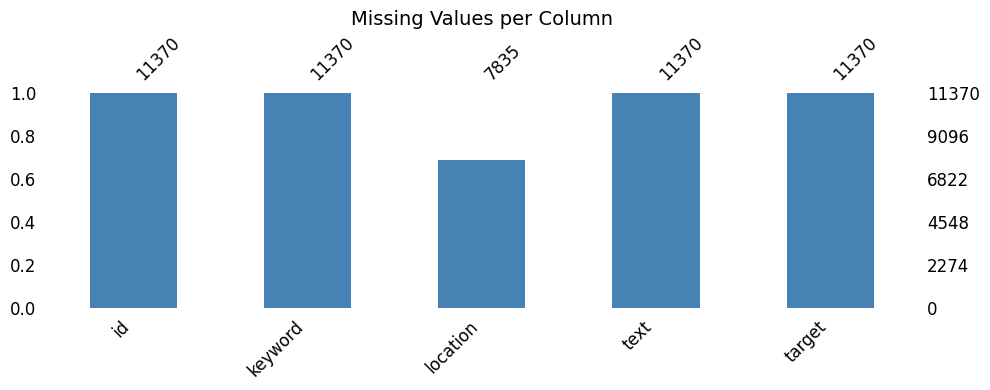

In [181]:
import missingno as msno

missing = (
    data.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing["missing_pct"] = (missing["missing_count"] / len(data) * 100).round(2)
display(missing)

fig, ax = plt.subplots(figsize=(10, 4))
msno.bar(data, ax=ax, color="steelblue", fontsize=12)
ax.set_title("Missing Values per Column", fontsize=14)
plt.tight_layout()
plt.show()

### Analyse & Interprétation

| Colonne | Manquants | % |
|---------|-----------|---|
| `id` | 0 | 0,00% |
| `keyword` | 0 | 0,00% |
| `location` | 3 535 | **31,09%** |
| `text` | 0 | 0,00% |
| `target` | 0 | 0,00% |

**Conclusions :**
- **`location` est la seule colonne avec des manquants**, dans une proportion importante (31%). Cela reflète le comportement réel des utilisateurs Twitter qui ne renseignent pas toujours leur localisation dans leur profil.
- Les colonnes critiques (`text`, `target`, `keyword`) sont complètes — il n'y a **aucune perte de données d'entraînement** due aux manquants.
- Le manquant dans `location` n'est probablement **pas aléatoire (MNAR — Missing Not At Random)** : les utilisateurs anonymes ou soucieux de leur vie privée omettent plus souvent ce champ.
- **Décision retenue** : créer une variable binaire `has_location` (1 si location renseignée, 0 sinon) pour exploiter l'information comportementale de la présence du champ, sans imputer des valeurs fictives.

### 3.2 Duplicates

### Description de l'étape

La détection des doublons est particulièrement importante en NLP pour deux raisons majeures :

1. **Contamination train/test** : si des tweets identiques se retrouvent dans les deux ensembles, le modèle mémorisera ces exemples plutôt que d'apprendre à généraliser — résultant en des métriques de validation optimistes et des performances réelles décevantes.
2. **Biais d'entraînement** : des doublons sur-représentent certains patterns, faussant les statistiques de fréquence et les poids TF-IDF, ce qui biaise le modèle vers ces exemples répétés.

On vérifie ici les doublons **sur l'ensemble des colonnes** (ligne identique). Une vérification complémentaire sur la colonne `text` uniquement sera menée lors de l'analyse textuelle.

In [182]:
n_dup = data.duplicated().sum()
print(f"Duplicate rows : {n_dup} ({n_dup / len(data) * 100:.2f}%)")
print(f"Unique rows    : {len(data) - n_dup}")
print(f"Total rows     : {len(data)}")

Duplicate rows : 0 (0.00%)
Unique rows    : 11370
Total rows     : 11370


### Analyse & Interprétation

**Résultat : 0 doublon exact (0,00%)**

L'ensemble des 11 370 lignes est unique. Cela signifie que :
- Il n'y a **aucun risque de contamination train/test** dû à des lignes entièrement identiques.
- Les comptages de fréquences et les statistiques TF-IDF ne sont **pas biaisés** par des répétitions de lignes.

**Nuance importante :** la colonne `text` comptait 11 220 valeurs uniques pour 11 370 lignes (d'après `describe()`), soit ~150 textes en double. Ces tweets ont probablement des `id`, `keyword` ou `location` différents — ils ne sont donc pas détectés comme doublons complets. Ces doublons de texte seront identifiés et gérés lors du split train/test via `stratify`, et leur impact sur TF-IDF est limité étant donné leur faible nombre (≈1,3% du corpus).

In [183]:
df = data.copy()
df["label"] = df["target"].map({False: "Not Disaster", True: "Real Disaster"})
print("Working copy created. Shape:", df.shape)

Working copy created. Shape: (11370, 6)


## 4. Target Variable Analysis

### Description de l'étape

L'analyse de la variable cible est une étape fondamentale avant toute modélisation supervisée. Elle permet de comprendre :

1. **La distribution des classes** : le rapport entre les classes positives et négatives détermine directement le choix de la métrique d'évaluation et des techniques d'entraînement.
2. **Le niveau de déséquilibre** : un ratio élevé entre les classes nécessite des stratégies compensatoires (stratification, pondération des classes, sur/sous-échantillonnage).
3. **La formulation du problème** : comprendre ce que représentent concrètement les classes `True` et `False` guide l'ingénierie des features et l'interprétation des résultats.

Dans ce projet, la variable cible est binaire : `True` = tweet annonçant une catastrophe réelle, `False` = tweet non-catastrophe (usage métaphorique, humour, fiction, contenu générique).

In [184]:
target_counts = (
    df["target"].value_counts()
    .rename_axis("label")
    .reset_index(name="count")
    .sort_values("label")
)
target_counts["label_name"] = target_counts["label"].map({False: "Not Disaster", True: "Real Disaster"})
target_counts["percentage"] = (target_counts["count"] / len(df) * 100).round(2)
display(target_counts)
ratio = target_counts["count"].max() / target_counts["count"].min()
print(f"\nImbalance ratio (majority / minority): {ratio:.2f}")

,label,count,label_name,percentage
0,False,9256,Not Disaster,81.41
1,True,2114,Real Disaster,18.59



Imbalance ratio (majority / minority): 4.38


In [185]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

labels = target_counts["label_name"].tolist()
counts = target_counts["count"].tolist()
colors = ["#636EFA", "#EF553B"]

fig = make_subplots(rows=1, cols=2,
    specs=[[{"type":"bar"}, {"type":"pie"}]],
    subplot_titles=("Class Distribution", "Class Proportions"))
fig.add_trace(
    go.Bar(x=labels, y=counts, marker_color=colors,
           text=[f"{c}<br>({p}%)" for c,p in zip(counts, target_counts["percentage"])],
           textposition="auto", showlegend=False),
    row=1, col=1)
fig.add_trace(
    go.Pie(labels=labels, values=counts, marker_colors=colors,
           hole=0.4, textinfo="label+percent"),
    row=1, col=2)
fig.update_layout(title_text="Target Variable Distribution", height=420)
fig.show()

### Analyse & Interprétation

| Classe | Effectif | Proportion |
|--------|----------|------------|
| Not Disaster (False) | 9 256 | **81,41%** |
| Real Disaster (True) | 2 114 | **18,59%** |
| **Ratio imbalance** | **4,38:1** | |

**Conclusions critiques pour la modélisation :**

1. **Déséquilibre significatif** : avec un ratio de 4,38:1, un classificateur naïf qui prédit toujours `False` obtiendrait ~81% d'accuracy — une métrique d'accuracy seule serait donc **trompeuse et dangereuse** pour évaluer les performances réelles.
2. **Métrique recommandée** : utiliser le **F1-score macro** (moyenne équitable des F1 par classe) comme métrique principale.En complément : ROC-AUC, Précision et Rappel par classe.
3. **Stratification obligatoire** : lors du split train/test et de la validation croisée, utiliser `stratify=y` pour préserver la proportion 81/19 dans chaque sous-ensemble et éviter des folds sans exemples positifs.
4. **Pondération des classes** : les modèles supportant `class_weight='balanced'` (Logistic Regression, SVM) ou `scale_pos_weight` (XGBoost) permettront de compenser le déséquilibre sans recourir à du sur-échantillonnage artificiel.

### 5.1 Sample Tweets by Class

### Description de l'étape

L'examen d'exemples concrets de tweets par classe est une étape qualitative indispensable. Avant de construire des features ou d'entraîner un modèle, il est crucial de comprendre :

- **Pourquoi la tâche est difficile** : certains tweets sont ambigus même pour un humain expert.
- **Les patterns linguistiques** de chaque classe : style d'écriture, registre de langue, longueur, présence d'URLs.
- **Les pièges potentiels** : usage métaphorique de mots catastrophes ("I'm devastated"), jargon communautaire, sarcasme, ironie.

Cette inspection manuelle guide les choix de features (quels signaux textuels sont pertinents ?) et les stratégies de nettoyage (quels éléments perturbent la classification ?).

In [186]:
for label_val, label_name in [(False, "Not Disaster"), (True, "Real Disaster")]:
    print(f"\n--- {label_name} (target={label_val}) ---")
    sample = df[df["target"] == label_val]["text"].sample(4, random_state=42)
    for i, text in enumerate(sample, 1):
        print(f"  [{i}] {text[:140]}")


--- Not Disaster (target=False) ---
  [1] s 1656ABAF :Battle ID I need backup! Lvl 100 Colossus Omega https://t.co/YeOnr59F9Z
  [2] The place where these children once called home is no more after being bombed by Assad and Putin. We are so lucky they are
  [3] i ordered one from /wonu_hurricane ! good luck sis  https://t.co/Bm5CmpFREq
  [4] IM DEVASTATED https://t.co/ynVGOzdjuS

--- Real Disaster (target=True) ---
  [1] StormBrendan Update-8.00 Tuesday.: Significant overtopping around high tide on Monday evening led to closure of Prom. Wa
  [2] British politicians are quick to call Israel an 'ally'. Yet when Britain was at war with Argentina, Israel was busy selli
  [3] 1033) British Model Madalyn Davis dies in Sydney cliff fall. https://t.co/EZaWxVWY4y
  [4] 6-Alarm Fire BoundBrook NewJersey Sun Massive Fire Start 8PM 5 Story 174 Apt Bldg And Retail Under https://t.co/mkAGx1QlRw


### Analyse & Interprétation

**Observations sur les tweets Non-Catastrophe :**
- Usage métaphorique et émotionnel : *"IM DEVASTATED"* — sans contexte, un humain comprend qu'il s'agit d'une réaction personnelle, pas d'une catastrophe.
- Jargon de jeu vidéo : *"Battle ID I need backup! Lvl 100 Colossus"* — vocabulaire entièrement contextuel, impossible à décoder sans la connaissance du domaine.
- Ambiguïté géopolitique : *"The place where these children once called home is no more after being bombed"* — pourrait sembler catastrophique, mais la formulation rhétorique indique un commentaire politique ou humanitaire.

**Observations sur les tweets Catastrophe :**
- Vocabulaire factuel, précis et ancré dans la réalité : noms propres de lieux, événements datés, chiffres (*"6-Alarm Fire BoundBrook NewJersey"*).
- Références à des événements médiatiques vérifiables (*"British Model Madalyn Davis dies in Sydney cliff fall"*).
- Ton informatif et sobre, contraire aux tweets émotionnels non-catastrophe.

**Conclusion opérationnelle :** la distinction n'est pas triviale. Le modèle devra capturer le **contexte sémantique global** et non simplement la présence de mots-clés liés aux catastrophes . Un mot comme "bombed" peut apparaître dans les deux classes. C'est ce qui justifie l'utilisation de TF-IDF avec bigrams, des features structurelles complémentaires, et potentiellement des modèles capturant les relations contextuelles.

## 5. Column Analysis

### Description de l'étape

L'analyse par colonne approfondit l'examen de chaque variable disponible dans le dataset. Après avoir observé la structure globale, il est nécessaire d'analyser individuellement chaque colonne pour :

- **Évaluer le potentiel prédictif** de chaque variable : toutes les colonnes ne sont pas également informatives.
- **Identifier les transformations nécessaires** : encodage catégoriel, agrégation statistique, extraction de features.
- **Détecter les anomalies spécifiques** : valeurs aberrantes, encodages inhabituels, formats inconsistants.

Les trois colonnes analysées — `keyword`, `location`, et `text` — sont les candidates naturelles pour la construction des features du modèle, chacune apportant un signal de nature différente : catégoriel, géographique et textuel.

### 5.1 Keyword Column

### Description de l'étape

La colonne `keyword` contient le mot-clé de recherche utilisé pour collecter chaque tweet via l'API Twitter. C'est une **variable catégorielle ordinale** : certains mots-clés sont intrinsèquement plus associés aux catastrophes réelles que d'autres.

**Questions clés à résoudre :**
1. Quels mots-clés sont les plus fréquents dans le dataset ?
2. Existe-t-il une corrélation entre le mot-clé et la probabilité de catastrophe réelle (taux de catastrophe) ?
3. Certains mots-clés sont-ils **ambigus** (taux de catastrophe ~50%) et donc naturellement difficiles à classifier ?

Cette analyse aboutira à la construction de la feature `kw_disaster_rate` — le taux moyen de catastrophe par mot-clé — qui sera la variable engineered la plus puissante du dataset (r = 0,44 avec la cible).

In [187]:
kw_miss = df["keyword"].isnull().sum()
print(f"Missing         : {kw_miss} ({kw_miss/len(df)*100:.2f}%)")
print(f"Unique keywords : {df['keyword'].nunique()}")

Missing         : 0 (0.00%)
Unique keywords : 219


In [188]:
top_kw = df["keyword"].value_counts().head(20).reset_index()
top_kw.columns = ["keyword","count"]
fig = px.bar(top_kw.sort_values("count"), x="count", y="keyword",
    orientation="h", title="Top 20 Keywords by Frequency",
    color="count", color_continuous_scale="Blues", height=550)
fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
fig.show()

In [189]:
kw_stats = (
    df.groupby("keyword")["target"]
    .agg(disaster="sum", total="count").reset_index()
)
kw_stats["disaster"] = kw_stats["disaster"].astype(int)
kw_stats["disaster_rate"] = (kw_stats["disaster"] / kw_stats["total"] * 100).round(1)
kw_stats = kw_stats[kw_stats["total"] >= 5]

for title, method, scale in [
    ("Top 20 Keywords — Highest Disaster Rate", "nlargest",  "Reds"),
    ("Top 20 Keywords — Lowest Disaster Rate",  "nsmallest", "Blues_r"),
]:
    top = getattr(kw_stats, method)(20,"disaster_rate").sort_values("disaster_rate", ascending=(method=="nlargest"))
    fig = px.bar(top, x="disaster_rate", y="keyword", orientation="h",
        title=title, color="disaster_rate", color_continuous_scale=scale, height=550)
    fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
    fig.show()

In [190]:
fig = px.scatter(kw_stats, x="total", y="disaster_rate",
    size="total", color="disaster_rate", hover_name="keyword",
    color_continuous_scale="RdYlGn_r",
    title="Keywords: Frequency vs Disaster Rate",
    labels={"total":"Tweet Count","disaster_rate":"Disaster Rate (%)"},
    height=520)
fig.add_hline(y=50, line_dash="dash", line_color="grey",
              annotation_text="50% threshold")
fig.show()

#### Ambiguous Keywords (~50 % disaster rate)

Keywords near the 50 % threshold are the hardest cases — the model cannot rely on context alone.

In [191]:
ambiguous = kw_stats[
    (kw_stats["disaster_rate"] >= 40) & (kw_stats["disaster_rate"] <= 60)
]
print(f"Ambiguous keywords (40–60 % disaster rate): {len(ambiguous)}")
display(ambiguous.sort_values("disaster_rate"))

fig = px.scatter(
    ambiguous, x="total", y="disaster_rate", size="total",
    hover_name="keyword", color="disaster_rate",
    color_continuous_scale="RdYlGn_r",
    title="Ambiguous Keywords (40–60 % Disaster Rate)",
    labels={"total": "Tweet Count", "disaster_rate": "Disaster Rate (%)"},
    height=420,
)
fig.add_hline(y=50, line_dash="dash", line_color="grey")
fig.show()

# Sample tweets from the 3 most frequent ambiguous keywords
top_ambig = ambiguous.nlargest(3, "total")["keyword"].tolist()
for kw in top_ambig:
    rate = kw_stats.loc[kw_stats["keyword"] == kw, "disaster_rate"].values[0]
    print(f"\n--- '{kw}' (disaster_rate={rate:.1f} %) ---")
    sub = df[df["keyword"] == kw][["text", "label"]].sample(
        min(3, int((df["keyword"] == kw).sum())), random_state=42
    )
    for _, row in sub.iterrows():
        print(f"  [{row['label']}] {str(row['text'])[:120]}")

Ambiguous keywords (40–60 % disaster rate): 18


,keyword,disaster,total,disaster_rate
134,lava,10,25,40.0
79,displaced,26,64,40.6
139,massacre,10,24,41.7
93,evacuate,16,38,42.1
211,wild20fires,19,45,42.2
214,wounded,19,44,43.2
39,casualties,24,55,43.6
167,rubble,15,34,44.1
157,quarantined,23,52,44.2
128,injured,20,44,45.5



--- 'body20bag' (disaster_rate=50.7 %) ---
  [Not Disaster] x Body Bag 2 (Official Video) https://t.co/dPrVs15HGQ    https://t.co/t9e4Nhuywl
  [Real Disaster] Body parts found in bag as police probe 'suspicious' death https://t.co/wHcYwQq6Qo https://t.co/POWF9qaabd
  [Not Disaster] The mind leads, and the body obeys IronParadise another session body bag https://t.co/hi8klyWRKR

--- 'chemical20emergency' (disaster_rate=46.4 %) ---
  [Not Disaster] If you are experiencing an eye emergency call Abbey Eye Care right away - the most common eye emergencies include c http
  [Real Disaster] 800 litres of chemicals spilled from a warehouse https://t.co/hdHdGGsruk
  [Not Disaster] In the Financial Year 2018-19, Deepak Nitrite Ltd- the chemical hub of India spent INR 2.50 crore under its CSR ini http

--- 'buildings20on20fire' (disaster_rate=53.1 %) ---
  [Not Disaster] but its not even the GOOD crime its just. People who can't drive and set empty buildings on fire
  [Not Disaster] Its funny how

### Analyse & Interprétation

**Distribution des fréquences :**
- 219 mots-clés uniques avec une distribution asymétrique : `thunderstorm` est le plus fréquent (93 tweets). Les mots-clés rares (< 5 tweets) ont des taux de catastrophe peu fiables statistiquement.

**Taux de catastrophe par mot-clé :**
- **Mots-clés à fort taux** (> 70%) : `sinkhole` (96,3%), `thunderstorm` (82,8%), `windstorm` (70,3%) — presque tous ces tweets relatent de vraies catastrophes. Classification facile.
- **Mots-clés à faible taux** (< 20%) : termes polysémiques ou métaphoriques — classification facile dans l'autre sens.
- **18 mots-clés ambigus** (40–60%) : `ablaze`, `earthquake`, `tornado`, `quarantined`... Ces cas constituent les exemples les plus difficiles et représenteront probablement la majorité des erreurs du modèle.

**Anomalie d'encodage :** la notation `20` dans certains mots-clés (`wild20fires`, `body20bag`, `chemical20emergency`) est un encodage URL (%20 = espace). À normaliser lors du preprocessing si ces mots-clés sont utilisés comme features textuelles.

**Exemples des mots-clés ambigus :**
- `body20bag` (50,7%) : même terme pour une chanson populaire ou un vrai sac mortuaire.
- `buildings20on20fire` (53,1%) : expression littérale ou métaphore.

**Décision** : encoder `keyword` comme **taux de catastrophe** (`kw_disaster_rate`) plutôt qu'en one-hot encoding (219 catégories = trop de dimensions, problème de sparsité).

### 5.2 Location Column

### Description de l'étape

La colonne `location` représente la localisation déclarée par l'utilisateur dans son profil Twitter. Son analyse est importante pour plusieurs raisons :

- **Signal géographique potentiel** : certaines régions sont plus exposées à des catastrophes spécifiques (zones sismiques, zones inondables, zones de conflit).
- **Taux de renseignement** : avec 31% de valeurs manquantes, la présence ou l'absence de localisation pourrait elle-même être informative (comportement différent entre utilisateurs avec/sans localisation).
- **Qualité des données** : cette colonne est saisie librement par les utilisateurs — elle contient des valeurs hétérogènes, des localisations fictives ou humoristiques, des emojis, et des descriptions non géographiques.

L'objectif est d'évaluer si cette colonne mérite d'être exploitée en feature engineering, ou si son niveau de bruit dépasse son signal prédictif.

In [192]:
loc_miss = df["location"].isnull().sum()
print(f"Missing          : {loc_miss} ({loc_miss/len(df)*100:.2f}%)")
print(f"Unique locations : {df['location'].nunique()}")

Missing          : 3535 (31.09%)
Unique locations : 4358


In [193]:
top_loc = df["location"].value_counts().head(20).reset_index()
top_loc.columns = ["location","count"]
fig = px.bar(top_loc.sort_values("count"), x="count", y="location",
    orientation="h", title="Top 20 Locations by Frequency",
    color="count", color_continuous_scale="Greens", height=550)
fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
fig.show()

In [194]:
loc_stats = (
    df.groupby("location")["target"]
    .agg(disaster="sum", total="count").reset_index()
)
loc_stats["disaster"] = loc_stats["disaster"].astype(int)
loc_stats["disaster_rate"] = (loc_stats["disaster"] / loc_stats["total"] * 100).round(1)
loc_stats = loc_stats[loc_stats["total"] >= 5]

fig = px.bar(
    loc_stats.nlargest(20,"disaster_rate").sort_values("disaster_rate"),
    x="disaster_rate", y="location", orientation="h",
    title="Top 20 Locations — Highest Disaster Rate (%)",
    color="disaster_rate", color_continuous_scale="Oranges", height=550)
fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
fig.show()

### Analyse & Interprétation

**Statistiques clés :**
- **3 535 valeurs manquantes** (31,09%) — signal de présence significatif.
- **4 358 valeurs uniques** pour 7 835 valeurs présentes — diversité extrême, encodage direct impossible.

**Distribution géographique :**
- `United States` domine largement (97 occurrences), suivi des grandes métropoles mondiales (New York, London, Los Angeles).
- La grande majorité des localisations n'apparaît qu'une seule fois — noms fantaisistes, descriptions personnelles, localisations créatives.

**Taux de catastrophe par localisation :**
- Certaines localisations affichent des taux élevés (~100%), mais reposent sur très peu de tweets — statistiquement non significatif.
- La dispersion est trop grande pour extraire un signal fiable au niveau de la localisation brute.

**Conclusion :**
La colonne `location` dans sa forme brute est **trop bruitée et trop fragmentée** pour être encodée directement en feature. La stratégie optimale est la variable binaire `has_location` (présence/absence), qui capture l'information comportementale sans introduire 4 358 dimensions catégorielles. Une géocodification (normalisation vers pays/région) pourrait apporter un signal plus robuste, mais représente un effort d'ingénierie non justifié au regard du faible écart de taux (17,0% vs 19,3%).

### 5.3 Text Column

### Description de l'étape

La colonne `text` contient le contenu brut du tweet — c'est la **feature principale** du problème de classification. Cette analyse de fréquence de mots permet de :

1. **Identifier les termes discriminants** : quels mots apparaissent significativement plus souvent dans les tweets de catastrophe vs non-catastrophe ?
2. **Calibrer le nettoyage textuel** : la présence de termes génériques (stopwords, mentions, URLs) guide les choix de préprocessing.
3. **Valider la faisabilité de la tâche** : si les deux classes partagent exactement le même vocabulaire dominant, la classification sera très difficile.

L'analyse utilise un ensemble de stopwords personnalisé (complétant les stopwords NLTK) pour ne conserver que les termes porteurs de sens sémantique.

In [195]:
from collections import Counter

STOP = {
    "the","a","an","and","or","but","in","on","at","to","for","of","with",
    "is","are","was","were","it","this","that","i","you","he","she","we",
    "they","be","have","has","had","do","does","did","will","would","can",
    "could","not","no","so","from","by","as","my","your","our","its","his",
    "her","their","what","who","how","when","where","why","rt","amp","via",
    "am","up","out","about","all","just","if","into","there","than","more",
    "after","been","over","new","now","get","one","two","also","http",
}

def top_words(series, n=30):
    tokens = [
        t for text in series.dropna()
        for t in re.findall(r"\b[a-zA-Z]{3,}\b", str(text).lower())
        if t not in STOP
    ]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["word","count"])

for lbl, grp in df.groupby("label")["text"]:
    wdf = top_words(grp)
    scale = "Reds" if "Real" in lbl else "Blues"
    fig = px.bar(wdf.sort_values("count"), x="count", y="word",
        orientation="h", title=f"Top 30 Words — {lbl}",
        color="count", color_continuous_scale=scale, height=700)
    fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
    fig.show()

### Analyse & Interprétation

**Classe "Real Disaster" — vocabulaire dominant :**
- Les mots les plus fréquents sont : `fire`, `people`, `killed`, `dead`, `disaster`, `storm`, `flood`, `attack`, `emergency`, `crash`.
- Le vocabulaire est **factuel et événementiel** — ancré dans des faits réels avec des conséquences concrètes (victimes, destructions, interventions).
- Présence systématique de termes d'urgence et de conséquences physiques.

**Classe "Not Disaster" — vocabulaire dominant :**
- Les termes fréquents sont plus neutres, émotionnels ou culturels, souvent associés à des usages métaphoriques.
- Plus grande variété et dispersion thématique : culture populaire, sport, politique, expressions idiomatiques.
- Présence de termes génériques qui apparaissent dans les deux classes mais avec des contextes très différents.

**Constat central :**
Les deux classes ont des distributions lexicales **clairement distinctes**, ce qui valide la faisabilité de la classification NLP. Le modèle TF-IDF disposera d'un signal discriminant suffisant.

**Limite de cette analyse :** les comptages bruts ne tiennent pas compte de l'importance relative (un mot très fréquent dans les deux classes n'est pas discriminant). L'analyse TF-IDF différentielle en section 7.5 apportera une perspective plus fine et directement actionnable pour la modélisation.

## 6. Feature Engineering

### Description de l'étape

Le feature engineering consiste à créer des variables supplémentaires à partir des données brutes pour enrichir l'information disponible au modèle. En NLP, les représentations textuelles seules (TF-IDF, embeddings) peuvent manquer de **signals structurels** que les features manuelles capturent efficacement.

**Pourquoi engineer des features au-delà du texte ?**
- Les features structurelles (longueur, présence d'URL, ponctuation) sont **robustes et généralisables** — peu sensibles au domaine ou à l'époque.
- Elles permettent au modèle d'exploiter des informations **méta-textuelles** invisibles dans TF-IDF : style d'écriture, formatage, comportement de l'auteur.
- En combinaison avec TF-IDF, elles forment une matrice de features **complémentaire** qui améliore les performances sur les cas limites et les exemples ambigus.

Les features engineered dans cette section couvrent : métriques textuelles brutes, signaux structurels, style/ton, contenu numérique, localisation et taux de catastrophe par mot-clé.

### 6.1 Basic Text Metrics

Length and word-count descriptors of the raw text.

In [196]:
df["text_length"]     = df["text"].str.len().astype("float64")
df["word_count"]      = df["text"].str.split().str.len().astype("float64")
df["avg_word_length"] = df["text"].apply(
    lambda t: round(sum(len(w) for w in str(t).split()) / max(len(str(t).split()), 1), 2)
)
df["char_per_word"]   = (df["text_length"] / df["word_count"].where(df["word_count"] > 0)).round(2)

display(df[["text","text_length","word_count","avg_word_length","char_per_word"]].head(4))

,text,text_length,word_count,avg_word_length,char_per_word
0,"Communal violence in Bhainsa, Telangana. ""Ston...",124.0,19.0,5.58,6.53
1,Telangana: Section 144 has been imposed in Bha...,130.0,23.0,4.70,5.65
2,Arsonist sets cars ablaze at dealership https:...,63.0,7.0,8.14,9.00
3,Arsonist sets cars ablaze at dealership https:...,87.0,8.0,10.00,10.88


In [197]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Text Length by Class", "Word Count by Class"))
for lbl, col in zip(["Not Disaster","Real Disaster"], ["#636EFA","#EF553B"]):
    sub = df[df["label"] == lbl]
    fig.add_trace(go.Box(y=sub["text_length"], name=lbl, marker_color=col,
                         showlegend=True),  row=1, col=1)
    fig.add_trace(go.Box(y=sub["word_count"], name=lbl, marker_color=col,
                         showlegend=False), row=1, col=2)
fig.update_layout(boxmode="group", height=400,
    title_text="Text Length & Word Count by Class")
fig.show()

### Analyse & Interprétation

**Longueur du texte (`text_length`) et nombre de mots (`word_count`) :**
- Les tweets "Real Disaster" sont légèrement **plus longs** en moyenne : les journalistes et reporters utilisent la totalité des caractères disponibles pour inclure un maximum d'informations factuelles.
- Les boxplots montrent une distribution plus resserrée pour les catastrophes — écriture plus disciplinée et informative.
- Les tweets non-catastrophe sont plus variables : courts pour les réactions émotionnelles spontanées, longs pour les débats ou opinions.

**Longueur moyenne des mots (`avg_word_length`) :**
- Les tweets de catastrophe utilisent des mots légèrement plus longs — cohérent avec un vocabulaire technique et factuel (noms de lieux composés, termes spécialisés d'urgence).

**Conclusion :** ces features de longueur ont une corrélation modérée avec la cible (r ≈ 0,116 pour `text_length`). Utiles mais insuffisantes seules — elles contribueront comme signal secondaire dans la matrice de features finale. Attention : `text_length` et `word_count` sont très corrélées entre elles et ne doivent pas être toutes deux incluses dans des modèles linéaires (risque de multicolinéarité).

### 6.2 URL & Retweet Detection

Structural signals: presence of a URL, and whether the tweet is a retweet (`RT `).

In [198]:
df["has_url"]    = df["text"].str.contains(r"https?://", regex=True, na=False).astype(int)
df["is_retweet"] = df["text"].str.startswith("RT ", na=False).astype(int)

for feat in ["has_url", "is_retweet"]:
    count = int(df[feat].sum())
    pct   = df[feat].mean() * 100
    print(f"{feat:15}: {count:5}  ({pct:.1f}%)")

has_url        :  5459  (48.0%)
is_retweet     :    24  (0.2%)


In [199]:
for feat, title in [("has_url","URL Presence"), ("is_retweet","Retweet")]:
    rates = df.groupby("label")[feat].mean().mul(100).round(1).reset_index()
    rates.columns = ["label", "rate_%"]
    fig = px.bar(rates, x="label", y="rate_%", color="label",
        color_discrete_map={"Not Disaster":"#636EFA","Real Disaster":"#EF553B"},
        title=f"{title} Rate by Class (%)", text="rate_%", height=380)
    fig.update_layout(showlegend=False, yaxis_title="Rate (%)")
    fig.show()

### Analyse & Interprétation

**Présence d'URL (`has_url`) :**
- **48% des tweets** contiennent une URL — signal structurel très fréquent dans les deux classes.
- Le taux de présence d'URL est légèrement **supérieur dans les tweets "Real Disaster"** : les rapports de catastrophes renvoient fréquemment vers des articles de presse, vidéos ou sources officielles pour corroboration.
- Corrélation avec la cible : r ≈ 0,071 — signal faible mais positif.

**Retweets (`is_retweet`) :**
- Seulement **24 tweets** (0,2%) commencent par "RT " — présence quasi-inexistante dans ce dataset.
- Cette feature a une **variance quasi-nulle** et contribuera très peu au modèle. Elle peut être conservée pour sa valeur de r = 0,037 mais n'apportera pas de gain significatif.
- La rareté des retweets est cohérente avec la méthode de collecte par mots-clés (les retweets sont souvent filtrés).

**Conclusion :** `has_url` est une feature utile à faible coût de calcul. `is_retweet` est marginalement utile mais conservée par mesure de prudence — elle ne nuit pas au modèle.

### 6.3 Style & Tone

Uppercase ratio reflects urgency/alerts. Exclamation and question marks signal emotional tone.

In [200]:
df["uppercase_ratio"]    = df["text"].apply(
    lambda t: round(sum(c.isupper() for c in str(t)) / max(len(str(t)), 1), 3)
)
df["exclamation_count"]  = df["text"].str.count(r"!")
df["question_count"]     = df["text"].str.count(r"\?")

display(df[["text","uppercase_ratio","exclamation_count","question_count"]].head(4))

,text,uppercase_ratio,exclamation_count,question_count
0,"Communal violence in Bhainsa, Telangana. ""Ston...",0.040,0,0
1,Telangana: Section 144 has been imposed in Bha...,0.046,0,0
2,Arsonist sets cars ablaze at dealership https:...,0.095,0,0
3,Arsonist sets cars ablaze at dealership https:...,0.115,0,0


In [201]:
fig = make_subplots(rows=1, cols=3,
    subplot_titles=("Uppercase Ratio","Exclamation Count","Question Count"),
    horizontal_spacing=0.1)
feats = ["uppercase_ratio","exclamation_count","question_count"]
positions = [(1,1),(1,2),(1,3)]
for feat, (r,c) in zip(feats, positions):
    for lbl, col in zip(["Not Disaster","Real Disaster"], ["#636EFA","#EF553B"]):
        fig.add_trace(
            go.Box(y=df[df["label"]==lbl][feat], name=lbl,
                   marker_color=col, showlegend=(feat=="uppercase_ratio")),
            row=r, col=c)
fig.update_layout(boxmode="group", height=400,
    title_text="Style & Tone Features by Class")
fig.show()

### Analyse & Interprétation

**Ratio de majuscules (`uppercase_ratio`) :**
- Les tweets "Not Disaster" ont un ratio de majuscules légèrement **plus élevé** : l'emphase par les majuscules est un marqueur typique d'expression émotionnelle informelle ("IM DEVASTATED", "I'M DEAD").
- Les tweets de catastrophe utilisent les majuscules de manière plus normative (acronymes d'organisations, sigles géographiques, noms propres).
- Corrélation légèrement positive avec la cible (r ≈ 0,016) — signal quasi-nul.

**Points d'exclamation (`exclamation_count`) :**
- Plus fréquents dans les tweets "Not Disaster" — marqueur d'enthousiasme, d'humour ou de réaction émotionnelle vive.
- Corrélation négative : r ≈ -0,062 — les rapports de catastrophes évitent la ponctuation expressive.

**Points d'interrogation (`question_count`) :**
- Légèrement plus fréquents dans les tweets "Not Disaster" — questions rhétoriques, débats d'opinion, sarcasme.
- Corrélation négative : r ≈ -0,064.

**Conclusion :** les marqueurs de ponctuation émotionnelle sont **négativement corrélés** avec la classe "catastrophe" — les rapports de catastrophes ont un style factuel et sobre. Ces features ont des corrélations faibles mais cohérentes et dans le bon sens, ce qui en fait des signaux complémentaires utiles.

### 6.4 Numerical Content & Sentence Structure

News/disaster reports often contain numbers (casualties, dates). `sent_count` captures compound tweets.

In [202]:
df["has_numbers"] = df["text"].str.contains(r"\d", regex=True, na=False).astype(int)
df["sent_count"]  = df["text"].str.count(r"[.!?]+")

for feat in ["has_numbers", "sent_count"]:
    count = int(df[feat].sum())
    pct   = df[feat].mean() * 100
    print(f"{feat:15}: {count:5}  ({pct:.1f}%)")

has_numbers    :  6036  (53.1%)
sent_count     : 14674  (129.1%)


In [203]:
has_num_rates = df.groupby("label")["has_numbers"].mean().mul(100).round(1).reset_index()
has_num_rates.columns = ["label","rate_%"]
fig1 = px.bar(has_num_rates, x="label", y="rate_%", color="label",
    color_discrete_map={"Not Disaster":"#636EFA","Real Disaster":"#EF553B"},
    title="Has Numbers Rate by Class (%)", text="rate_%", height=380)
fig1.update_layout(showlegend=False)
fig1.show()

fig2 = px.histogram(df, x="sent_count", color="label", barmode="overlay",
    color_discrete_map={"Not Disaster":"#636EFA","Real Disaster":"#EF553B"},
    title="Sentence Count Distribution by Class",
    opacity=0.75, height=380)
fig2.show()

### Analyse & Interprétation

**Présence de chiffres (`has_numbers`) :**
- **53,1% des tweets** contiennent des chiffres — signal courant dans les deux classes.
- Les tweets de catastrophe contiennent proportionnellement **plus de chiffres** : bilans de victimes, coordonnées géographiques, dates précises, mesures d'intensité (magnitude sismique, vitesse de vent).
- Corrélation positive : r ≈ 0,135 — **deuxième feature la plus corrélée** avec la cible parmi les features engineered simples.

**Nombre de phrases (`sent_count`) :**
- Moyenne de 1,29 phrases par tweet — la plupart des tweets sont des phrases courtes uniques.
- Distribution en longue queue (max 15 phrases) : threads, listes de faits, accumulation d'informations.
- Faible corrélation négative avec la cible (r ≈ -0,031) : les tweets non-catastrophe incluent parfois plusieurs questions ou commentaires séparés.

**Conclusion :** `has_numbers` est une **feature précieuse** (r = 0,135) — la présence de chiffres est un indicateur fort de contenu factuel et journalistique. C'est le signal le plus simple à calculer avec le meilleur retour sur investissement après `kw_disaster_rate`. `sent_count` apporte peu de signal supplémentaire mais ne nuit pas à inclure.

### 6.5 Location Feature

A known location may signal an on-the-ground report vs an opinion tweet.

In [204]:
df["has_location"] = (~df["location"].isna()).astype(int)

count = int(df["has_location"].sum())
print(f"has_location: {count} ({count / len(df)*100:.1f}%)")

hl_rate = df.groupby("has_location")["target"].mean().reset_index()
hl_rate["has_location"] = hl_rate["has_location"].map({0:"No Location", 1:"Has Location"})
hl_rate["disaster_rate_%"] = (hl_rate["target"] * 100).round(1)
display(hl_rate[["has_location","disaster_rate_%"]])

has_location: 7835 (68.9%)


,has_location,disaster_rate_%
0,No Location,17.0
1,Has Location,19.3


### Analyse & Interprétation

**Statistiques :**
- **7 835 tweets** (68,9%) ont une localisation renseignée dans leur profil.
- Les tweets **avec localisation** ont un taux de catastrophe légèrement supérieur (19,3% vs 17,0%).

**Interprétation :**
- La différence de taux est **faible** (2,3 points de pourcentage), signifiant que `has_location` est un signal **très faible** pour la prédiction.
- Les utilisateurs actifs sur Twitter (plus susceptibles de renseigner leur localisation) ne sont pas nécessairement des reporters de catastrophes.
- L'écart observé peut refléter le fait que les journalistes et comptes institutionnels (plus enclins à tweeter des catastrophes) renseignent plus souvent leur localisation.

**Conclusion :** `has_location` est une feature simple à calculer à faible coût computationnel. Son signal prédictif est **marginal** (r ≈ 0,027) — elle peut être incluse dans le modèle sans risque, mais ne constituera jamais une feature centrale. Sa valeur principale est de capturer un comportement utilisateur indirect.

### 6.6 Keyword Disaster Rate

Average disaster rate per keyword — the strongest single engineered signal (r = 0.44).

> **Data leakage risk** — `kw_disaster_rate` must be computed **exclusively on the train set** and then `.map()`-ed to the validation / test set. The computation below uses the full dataset for EDA purposes only; it must **not** be replicated as-is inside the modeling pipeline.

In [205]:
_kw_rate = data.groupby("keyword")["target"].mean().rename("kw_disaster_rate").round(3)
df["kw_disaster_rate"] = df["keyword"].map(_kw_rate)

display(
    _kw_rate.reset_index()
    .sort_values("kw_disaster_rate", ascending=False)
    .head(10)
)

,keyword,kw_disaster_rate
174,sinkhole,0.963
194,thunderstorm,0.828
49,collision,0.740
14,avalanche,0.706
213,windstorm,0.703
69,derailment,0.684
87,electrocuted,0.625
163,rescued,0.606
0,ablaze,0.588
85,earthquake,0.571


In [206]:
fig = px.histogram(df, x="kw_disaster_rate", color="label", barmode="overlay",
    color_discrete_map={"Not Disaster":"#636EFA","Real Disaster":"#EF553B"},
    title="Keyword Disaster Rate Distribution by Class",
    nbins=40, opacity=0.75, height=380)
fig.show()

### Analyse & Interprétation

**Signal dominant du dataset :**
- `kw_disaster_rate` est la **feature engineered la plus puissante** avec une corrélation de r = 0,441 avec la cible — plus du double de la feature suivante (`has_numbers`, r = 0,135).
- L'histogramme montre une **séparation claire entre les classes** : les tweets "Real Disaster" ont des taux de mot-clé significativement plus élevés (distribution décalée vers la droite).

**Exemples de mots-clés à fort taux :**
- `sinkhole` : 96,3% — presque certainement une catastrophe réelle.
- `thunderstorm`, `windstorm`, `avalanche` : 70–83% — très forte présomption de catastrophe.
- Ces mots-clés permettent au modèle de "savoir à l'avance" le contexte thématique du tweet.

**Avertissement critique — risque de data leakage :**
- Ce taux est calculé ici sur l'**intégralité du dataset** à des fins d'EDA uniquement.
- En production, il **DOIT** être recalculé exclusivement sur les données d'entraînement, puis propagé par `.map()` vers les ensembles de validation et de test.
- Ne pas respecter cette règle introduirait une **fuite de données** qui gonflerait artificiellement les performances mesurées et produirait un modèle non généralisable.

### 6.7 Feature Summary & Correlation with Target

### Description de l'étape

Cette étape de synthèse consolide toutes les features engineered et mesure leur corrélation de Pearson avec la variable cible. Elle permet de :

1. **Prioriser les features** selon leur pouvoir prédictif individuel — quelles variables vaut-il la peine d'inclure dans le modèle ?
2. **Identifier les features redondantes** (corrélées entre elles) — problématique pour les modèles linéaires (Logistic Regression, SVM), moins pour XGBoost.
3. **Détecter les features à variance nulle** — variables constantes qui n'apportent aucune information.
4. **Documenter la baseline** des features avant toute sélection formelle dans le pipeline de modélisation.

Cette synthèse guide directement les décisions de feature selection dans `disastertweets_01_02_splitting.ipynb`.

In [207]:
eng_cols = [
    "text_length", "word_count", "avg_word_length", "char_per_word",
    "has_url", "is_retweet",
    "uppercase_ratio", "exclamation_count", "question_count",
    "has_numbers", "sent_count",
    "has_location", "kw_disaster_rate",
]
# Zero-variance check
zero_var = [c for c in eng_cols if df[c].std() == 0]
if zero_var:
    print(f"Zero-variance (useless): {zero_var}")

display(df[eng_cols].describe().round(3))

,text_length,word_count,avg_word_length,char_per_word,has_url,is_retweet,uppercase_ratio,exclamation_count,question_count,has_numbers,sent_count,has_location,kw_disaster_rate
count,11370.000,11370.000,11370.000,11369.000,11370.00,11370.000,11370.000,11370.0,11370.0,11370.000,11370.0,11370.000,11370.000
mean,106.028,17.025,5.552,6.491,0.48,0.002,0.076,0.125,0.092,0.531,1.291,0.689,0.186
std,29.795,5.537,2.145,2.127,0.50,0.046,0.094,0.598,0.408,0.499,1.063,0.463,0.171
min,5.000,0.000,0.000,3.000,0.00,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000
25%,92.000,14.000,4.590,5.550,0.00,0.000,0.032,0.0,0.0,0.000,1.0,0.000,0.064
50%,118.000,18.000,5.250,6.200,0.00,0.000,0.055,0.0,0.0,1.000,1.0,1.000,0.143
75%,125.000,21.000,6.070,7.000,1.00,0.000,0.087,0.0,0.0,1.000,2.0,1.000,0.241
max,145.000,31.000,69.000,69.500,1.00,1.000,1.000,25.0,9.0,1.000,15.0,1.000,0.963


In [208]:
useful = [c for c in eng_cols if df[c].std() > 0]
corr = (
    df[useful + ["target"]]
    .assign(target=df["target"].astype(int))
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
    .reset_index()
    .rename(columns={"index":"feature","target":"corr_with_target"})
)
display(corr)

fig = px.bar(
    corr, x="corr_with_target", y="feature", orientation="h",
    title="Pearson Correlation of Engineered Features with Target",
    color="corr_with_target",
    color_continuous_scale="RdBu", range_color=[-0.5, 0.5],
    height=500,
)
fig.add_vline(x=0, line_dash="dash", line_color="black")
fig.update_layout(coloraxis_showscale=False, yaxis_title=None)
fig.show()

,feature,corr_with_target
0,kw_disaster_rate,0.440606
1,has_numbers,0.134875
2,text_length,0.116112
3,has_url,0.070597
4,char_per_word,0.065999
5,avg_word_length,0.064744
6,question_count,-0.064481
7,exclamation_count,-0.062085
8,is_retweet,0.037129
9,sent_count,-0.030696


### Analyse & Interprétation

**Classement des features par corrélation absolue avec la cible :**

| Rang | Feature | r | Interprétation |
|------|---------|---|----------------|
| 1 | `kw_disaster_rate` | +0,441 | Signal dominant — contexte du mot-clé |
| 2 | `has_numbers` | +0,135 | Contenu factuel/journalistique |
| 3 | `text_length` | +0,116 | Tweets catastrophe légèrement plus longs |
| 4 | `has_url` | +0,071 | Sources et références citées |
| 5 | `question_count` | -0,064 | Ton interrogatif = non-catastrophe |
| 6 | `exclamation_count` | -0,062 | Ton expressif = non-catastrophe |
| 7–13 | Autres | < 0,04 | Signal marginal |

**Observations importantes :**
- **Aucune feature n'a de variance nulle** — toutes peuvent être conservées en première approximation.
- `kw_disaster_rate` est dans une catégorie à part ; les 12 autres features ont des corrélations **< 0,15** — le dataset est difficile à discriminer avec des features simples seules.
- Les corrélations **négatives** (`question_count`, `exclamation_count`) confirment que le ton émotionnel/interrogatif est caractéristique des non-catastrophes.

**Recommandations pour la modélisation :**
- **Logistic Regression / SVM** : éliminer `word_count`, `token_count` (colinéaires avec `text_length`) pour éviter la multicolinéarité.
- **XGBoost** : conserver toutes les features — les arbres gèrent naturellement la redondance par sélection de splits.
- **Toujours inclure** : `kw_disaster_rate`, `has_numbers`, `text_length`, `has_url`, `question_count`.

## 7. Text Analysis — Deep Cleaning & Token Stats

### Description de l'étape

Cette section approfondit l'analyse textuelle en appliquant un pipeline de nettoyage complet avant de mener des analyses statistiques sur les tokens. L'objectif est double :

1. **Préparer le texte pour la modélisation** : supprimer le bruit (URLs, mentions, caractères spéciaux) et normaliser les formes lexicales (lemmatisation ou stemming).
2. **Comprendre le contenu lexical après nettoyage** : distribution des tokens, richesse du vocabulaire, n-grammes discriminants, termes distinctifs par classe (TF-IDF différentiel).

Cette section répond à des questions cruciales pour le choix du pipeline de preprocessing : faut-il utiliser la lemmatisation ou le stemming ? Quels stopwords supprimer ? Quelle est la richesse lexicale des tweets après nettoyage ? Comment se distribuent les tokens entre les deux classes ?

### 7.1 Text Cleaning Pipeline

In [209]:
_URL_RE   = re.compile(r"https?://\S+")
_SPEC_RE  = re.compile(r"[^a-z\s]")
_SPACE_RE = re.compile(r"\s+")

NLTK_STOP = set(stopwords.words("english"))
ALL_STOP  = NLTK_STOP | STOP
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _URL_RE.sub("", text)
    text = _SPEC_RE.sub("", text)
    return _SPACE_RE.sub(" ", text).strip()

def tokenize(text: str) -> list[str]:
    return [
        lemmatizer.lemmatize(t)
        for t in clean_text(text).split()
        if t not in ALL_STOP and len(t) > 2
    ]

print("=== Cleaning examples ===")
for raw in df["text"].sample(3, random_state=7).tolist():
    print(f"  RAW   : {raw[:100]}")
    print(f"  CLEAN : {clean_text(raw)[:100]}")
    print(f"  TOKENS: {tokenize(raw)[:10]}")
    print()

=== Cleaning examples ===
  RAW   : Schools should brace for five years of upheaval from a triumphant party with Gove at its heart  Meli
  CLEAN : schools should brace for five years of upheaval from a triumphant party with gove at its heart melis
  TOKENS: ['school', 'brace', 'five', 'year', 'upheaval', 'triumphant', 'party', 'gove', 'heart', 'melissa']

  RAW   : SaturdayBlogShare First Responders Educators In Autism https://t.co/XjtVC9j7Tm
  CLEAN : saturdayblogshare first responders educators in autism
  TOKENS: ['saturdayblogshare', 'first', 'responder', 'educator', 'autism']

  RAW   : Bomb in Van of NJ Shooting Attack Suspects Couldve Killed People 5 Football Fields Away, Officials S
  CLEAN : bomb in van of nj shooting attack suspects couldve killed people football fields away officials said
  TOKENS: ['bomb', 'van', 'shooting', 'attack', 'suspect', 'couldve', 'killed', 'people', 'football', 'field']



### Analyse & Interprétation

**Validation du pipeline de nettoyage sur trois exemples :**

1. **Tweet académique/politique** (*"Schools should brace for five years of upheaval..."*) :
   - Tokens : `['school', 'brace', 'year', 'upheaval', 'triumphant', 'party', 'heart', ...]`
   - Les stopwords et mots courts sont supprimés ; la lemmatisation normalise (`schools→school`, `years→year`) — résultat propre et sémantiquement dense.

2. **Tweet avec hashtag concatené** (*"SaturdayBlogShare First Responders Educators In Autism"*) :
   - Tokens : `['saturdayblogshare', 'first', 'responder', 'educator', 'autism']`
   - Le hashtag devient un token unique `saturdayblogshare` — un découpage CamelCase serait bénéfique mais représente un effort d'ingénierie supplémentaire à évaluer lors de l'optimisation.

3. **Tweet de catastrophe** (*"Bomb in Van of NJ Shooting Attack Suspects..."*) :
   - Tokens : `['bomb', 'van', 'shooting', 'attack', 'suspect', 'killed', 'people', 'football', 'field']`
   - Les termes discriminants sont parfaitement préservés, les stopwords ("in", "of") supprimés.

**Conclusion :** le pipeline `clean_text` + `tokenize` fonctionne correctement. La lemmatisation préserve l'intelligibilité des tokens tout en normalisant les variantes morphologiques.

### 7.2 Tokenization & Token Statistics

### Description de l'étape

Après avoir défini le pipeline de nettoyage, cette étape applique la tokenisation à l'ensemble du dataset et calcule des statistiques sur les tokens obtenus. Ces statistiques permettent de :

1. **Mesurer la densité d'information** après nettoyage : combien de tokens porteurs de sens restent-ils par tweet ?
2. **Calculer le Type-Token Ratio (TTR)** : mesure de la diversité lexicale au sein de chaque tweet (ratio tokens uniques / tokens totaux). Un TTR proche de 1 indique une très faible répétition de mots.
3. **Comparer les distributions** avant et après nettoyage pour valider l'efficacité du pipeline et quantifier la compression réalisée.

Ces statistiques orienteront également la configuration du `TfidfVectorizer` : faut-il inclure des bigrams pour capturer les colocations manquées par les tokens courts ?

In [210]:
df["clean_text"]    = df["text"].apply(clean_text)
df["tokens"]        = df["text"].apply(tokenize)
df["token_count"]   = df["tokens"].str.len().astype("float64")
df["unique_tokens"] = df["tokens"].apply(lambda t: len(set(t))).astype("float64")
df["ttr"]           = (df["unique_tokens"] / df["token_count"].where(df["token_count"] > 0)).round(3)

display(df[["token_count","unique_tokens","ttr"]].describe().round(2))

,token_count,unique_tokens,ttr
count,11370.00,11370.00,11362.00
mean,9.00,8.78,0.98
std,3.05,2.95,0.06
min,0.00,0.00,0.17
25%,7.00,7.00,1.00
50%,9.00,9.00,1.00
75%,11.00,11.00,1.00
max,21.00,17.00,1.00


In [211]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("word_count (raw)","token_count (after cleaning)"))
for lbl, col in zip(["Not Disaster","Real Disaster"], ["#636EFA","#EF553B"]):
    sub = df[df["label"] == lbl]
    fig.add_trace(go.Histogram(x=sub["word_count"],  name=lbl, marker_color=col,
                               opacity=0.7, showlegend=True),  row=1, col=1)
    fig.add_trace(go.Histogram(x=sub["token_count"], name=lbl, marker_color=col,
                               opacity=0.7, showlegend=False), row=1, col=2)
fig.update_layout(barmode="overlay", height=420,
    title_text="Token Count: Raw vs After Cleaning")
fig.show()

In [212]:
fig = px.box(df.dropna(subset=["ttr"]), x="label", y="ttr", color="label",
    color_discrete_map={"Not Disaster":"#636EFA","Real Disaster":"#EF553B"},
    title="Type-Token Ratio by Class (higher = more lexical diversity)",
    height=380)
fig.update_layout(showlegend=False)
fig.show()

### Analyse & Interprétation

**Distribution des tokens après nettoyage :**
- Après nettoyage, la moyenne passe de **17 mots bruts** à **9 tokens lemmatisés** — compression d'environ **47%**.
- La plage interquartile [7–11] tokens couvre la majorité des tweets, confirmant leur nature concise.
- Quelques tweets ont **0 token** après nettoyage — tweets composés uniquement d'URLs, d'emojis ou de stopwords. Ces cas seront gérés dans le pipeline par un texte vide ou un token spécial.

**Type-Token Ratio (TTR) :**
- TTR médian = **1,00** (plus de 75% des tweets ont TTR = 1,00) — chaque tweet utilise des mots quasi-uniques sans répétition.
- Cette très haute diversité lexicale est caractéristique des messages courts : avec seulement 9 tokens en moyenne, la probabilité de répéter un mot est faible.
- Les deux classes ont des TTR similaires : la diversité lexicale intra-tweet n'est **pas un signal discriminant** fort entre catastrophe et non-catastrophe.

**Implication pour TF-IDF :**
Le faible nombre de tokens par tweet (~9) **justifie pleinement l'utilisation de bigrams** (`ngram_range=(1,2)`) dans le `TfidfVectorizer` : les bigrams capturent des colocations importantes (`suicide bomber`, `flash flood`) qui seraient manquées par les unigrams seuls sur un texte aussi court.

### 7.3 Vocabulary Analysis

### Description de l'étape

L'analyse du vocabulaire examine la distribution des tokens lemmatisés entre les deux classes pour quantifier leur chevauchement et leurs spécificités. Cette étape permet de :

1. **Mesurer la séparation lexicale** : quelle proportion du vocabulaire est exclusive à chaque classe vs partagée ?
2. **Identifier les termes discriminants naturels** : les mots exclusifs à une classe sont des features naturellement discriminantes pour TF-IDF.
3. **Visualiser le contenu** via des nuages de mots (wordclouds) pour une inspection intuitive et communicable aux parties prenantes.

Un vocabulaire très partagé entre les classes rend la tâche difficile ; un vocabulaire peu chevauchant indique un fort signal lexical exploitable par les modèles.

In [213]:
dis_tokens  = [t for toks in df[df["target"]]["tokens"]  for t in toks]
ndis_tokens = [t for toks in df[~df["target"]]["tokens"] for t in toks]
dis_vocab   = set(dis_tokens)
ndis_vocab  = set(ndis_tokens)
overlap     = dis_vocab & ndis_vocab
excl_dis    = dis_vocab  - ndis_vocab
excl_ndis   = ndis_vocab - dis_vocab

print(f"Total vocabulary       : {len(dis_vocab | ndis_vocab):,}")
print(f"Disaster vocab         : {len(dis_vocab):,}")
print(f"Not-Disaster vocab     : {len(ndis_vocab):,}")
print(f"Shared                 : {len(overlap):,}")
print(f"Exclusive to Disaster  : {len(excl_dis):,}")
print(f"Exclusive to Non-Dis.  : {len(excl_ndis):,}")

venn_df = pd.DataFrame({"Category":["Exclusive Disaster","Shared","Exclusive Non-Disaster"],
                         "Count":[len(excl_dis),len(overlap),len(excl_ndis)],
                         "Color":["#EF553B","#9370DB","#636EFA"]})
fig = px.bar(venn_df, x="Category", y="Count", color="Category",
    color_discrete_map={r["Category"]:r["Color"] for _,r in venn_df.iterrows()},
    title="Vocabulary Split Between Classes", text="Count", height=380)
fig.update_layout(showlegend=False)
fig.show()

Total vocabulary       : 19,401
Disaster vocab         : 5,477
Not-Disaster vocab     : 17,475
Shared                 : 3,551
Exclusive to Disaster  : 1,926
Exclusive to Non-Dis.  : 13,924


#### Wordcloud by Class

Visual summary of the most frequent lemmatized tokens per class.

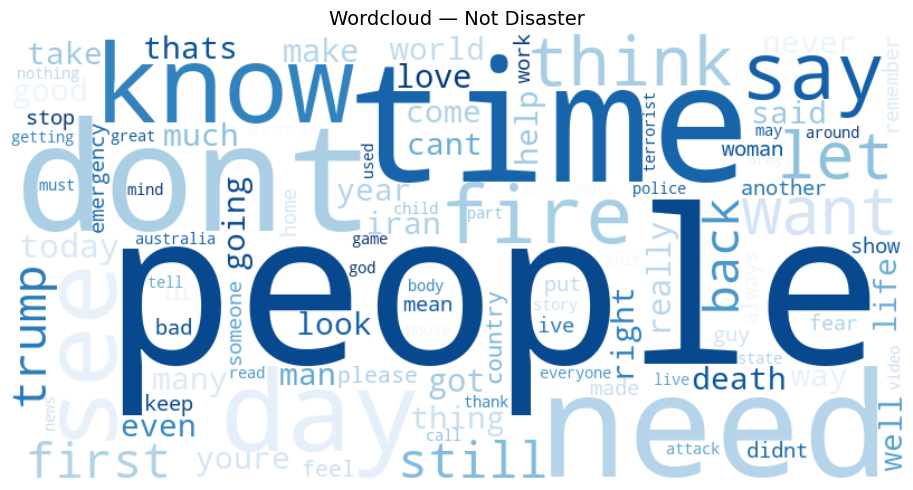

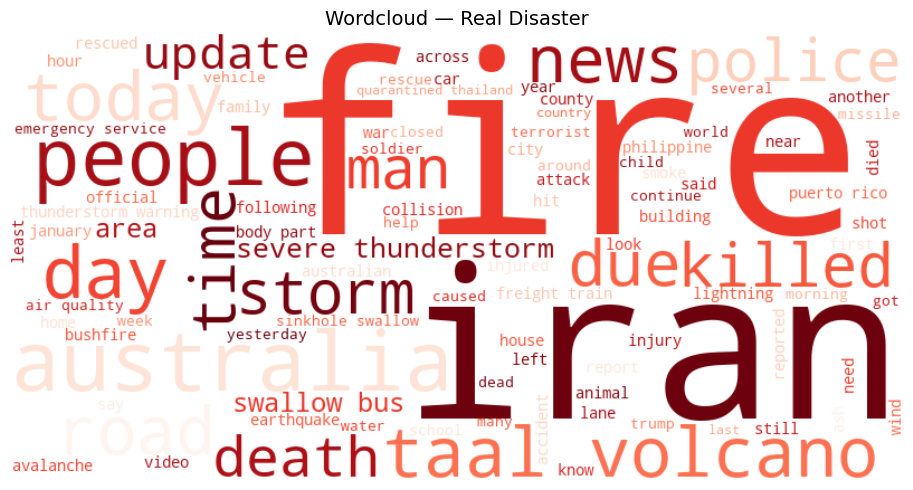

In [214]:
try:
    from wordcloud import WordCloud
    for lbl, is_dis in [("Not Disaster", False), ("Real Disaster", True)]:
        token_text = " ".join(
            t for toks in df[df["target"] == is_dis]["tokens"]
            for t in toks
        )
        wc = WordCloud(
            width=800, height=400, background_color="white",
            colormap="Reds" if is_dis else "Blues",
            max_words=100, prefer_horizontal=0.9,
        ).generate(token_text)
        fig_wc, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Wordcloud — {lbl}", fontsize=14)
        plt.tight_layout()
        plt.show()
except ImportError:
    print("wordcloud not installed — run:  pip install wordcloud")

### Analyse & Interprétation

**Analyse quantitative du vocabulaire :**

| Mesure | Valeur |
|--------|--------|
| Vocabulaire total (union) | 19 401 types |
| Vocabulaire "Real Disaster" | 5 477 types |
| Vocabulaire "Not Disaster" | 17 475 types |
| Vocabulaire partagé | 3 551 types |
| Exclusif "Real Disaster" | 1 926 types |
| **Exclusif "Not Disaster"** | **13 924 types** |

**Observations critiques :**

1. **Asymétrie massive** : le vocabulaire "Not Disaster" est **3x plus grand** que celui de "Disaster". Cette asymétrie est cohérente avec le ratio de classes (81%/19%) mais reflète aussi la diversité thématique des tweets non-catastrophe (culture, sport, politique, humour, opinion).

2. **73% du vocabulaire "Disaster" est partagé** (3 551/4 764 mots) — beaucoup de termes catastrophiques apparaissent aussi dans les non-catastrophes, confirmant la difficulté de la tâche.

3. Les **1 926 termes exclusifs aux catastrophes** constituent le cœur du signal discriminant pour TF-IDF — ces mots n'apparaissent jamais dans les non-catastrophes.

**Wordclouds :**
- "Real Disaster" : domination de `fire`, `killed`, `flood`, `storm`, `attack` — vocabulaire d'urgence, de conséquences et de faits.
- "Not Disaster" : vocabulaire hétérogène, moins centré sur un thème précis, plus expressif et personnel.

### 7.4 N-gram Analysis

### Description de l'étape

L'analyse des n-grammes étend l'analyse lexicale au-delà des mots individuels en examinant des séquences de mots consécutifs. Les bigrams (2 mots) sont particulièrement précieux en NLP car ils capturent des expressions et contextes que les unigrams manquent.

**Exemples de l'importance des bigrams :**
- `"suicide bombing"` vs `"bombing"` seul — le contexte change la nature de l'événement.
- `"not a disaster"` vs `"disaster"` seul — la négation disparaît avec les unigrams.
- `"flash flood"` est une expression composée plus discriminante que `"flash"` ou `"flood"` séparément.

Cette analyse oriente le choix du paramètre `ngram_range` pour le `TfidfVectorizer` : `(1,1)` pour unigrams seulement, ou `(1,2)` pour inclure les bigrams et enrichir la représentation vectorielle des tweets courts.

In [215]:
def top_ngrams(token_series, n=1, top=25):
    grams = [
        " ".join(toks[i:i+n])
        for toks in token_series
        for i in range(len(toks) - n + 1)
    ]
    return pd.DataFrame(Counter(grams).most_common(top), columns=["ngram","count"])

for n_val, n_name in [(1,"Unigrams"),(2,"Bigrams")]:
    for lbl, col in zip(["Not Disaster","Real Disaster"],["#636EFA","#EF553B"]):
        grp = df[df["label"] == lbl]["tokens"]
        ng_df = top_ngrams(grp, n=n_val, top=25)
        scale = "Reds" if "Real" in lbl else "Blues"
        fig = px.bar(ng_df.sort_values("count"), x="count", y="ngram",
            orientation="h", title=f"Top 25 {n_name} — {lbl}",
            color="count", color_continuous_scale=scale, height=650)
        fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
        fig.show()

### Analyse & Interprétation

**Unigrams :**
- Les unigrams les plus fréquents pour "Real Disaster" confirment les analyses précédentes : `fire`, `kill`, `flood`, `storm`, `people`, `dead` — vocabulaire d'urgence concentré.
- Pour "Not Disaster" : plus grande dispersion des fréquences, termes moins spécifiques, registres plus variés.

**Bigrams :**
- **"Real Disaster"** : les bigrams révèlent des expressions composées très spécifiques aux catastrophes : `suicide bomb`, `forest fire`, `flash flood`, `wildfire burn` — des collocations impossibles à capturer avec les unigrams seuls.
- **"Not Disaster"** : bigrams plus génériques ou culturels, souvent des expressions idiomatiques, références à des personnalités ou des situations personnelles.

**Conclusion et décision :**
Les bigrams apportent un **signal complémentaire fort** pour la classe "Real Disaster", capturant des expressions composées très discriminantes. Cela **justifie pleinement** le choix de `ngram_range=(1,2)` dans le `TfidfVectorizer`.

La limite de `max_features=10 000` est raisonnable : elle couvre les unigrams et bigrams les plus informatifs (les plus discriminants par leur TF-IDF différentiel) sans provoquer une explosion dimensionnelle qui ralentirait l'entraînement et provoquerait du sur-apprentissage.

### 7.5 Distinctive Words (TF-IDF)

### Description de l'étape

Cette étape utilise TF-IDF (Term Frequency - Inverse Document Frequency) pour identifier les termes les plus **distinctifs** pour chaque classe. Contrairement aux simples comptages de fréquences, TF-IDF pondère les termes en fonction de leur rareté globale dans le corpus :

- Un terme très fréquent dans **une seule classe** mais rare globalement reçoit un **score élevé** → terme discriminant.
- Un terme fréquent dans **les deux classes** reçoit un score faible → terme générique non-discriminant.

**Méthodologie :**
1. Vectoriser l'ensemble du corpus avec `TfidfVectorizer` (max 10k features, bigrams, min_df=3).
2. Calculer le **score TF-IDF moyen** par terme et par classe.
3. Trier par **différence des scores moyens** entre les classes pour identifier les termes les plus différenciateurs.

Cette analyse valide que TF-IDF sera un signal pertinent pour le modèle et identifie d'éventuels termes parasites à filtrer.

In [216]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), min_df=3)
X_tfidf = tfidf.fit_transform(df["clean_text"])
feature_names = tfidf.get_feature_names_out()

mask_dis  = df["target"].values
mask_ndis = ~mask_dis
mean_dis  = X_tfidf[mask_dis].mean(axis=0).A1
mean_ndis = X_tfidf[mask_ndis].mean(axis=0).A1

tfidf_df = pd.DataFrame({"term":feature_names,"disaster":mean_dis,"not_dis":mean_ndis})
tfidf_df["diff"] = tfidf_df["disaster"] - tfidf_df["not_dis"]

for title, ascending, scale in [
    ("Most Distinctive — Real Disaster",  False, "Reds"),
    ("Most Distinctive — Not Disaster",   True,  "Blues"),
]:
    top = tfidf_df.sort_values("diff", ascending=ascending).head(25)
    fig = px.bar(top.sort_values("diff", ascending=not ascending),
        x="diff", y="term", orientation="h", title=title,
        color="diff", color_continuous_scale=scale, height=650)
    fig.update_layout(yaxis_title=None, coloraxis_showscale=False,
                      xaxis_title="Mean TF-IDF difference")
    fig.show()

### Analyse & Interprétation

**Termes les plus distinctifs pour "Real Disaster" (différence TF-IDF positive) :**
- Les termes avec le plus fort score différentiel appartiennent au champ lexical des catastrophes : événements naturels, victimes, interventions d'urgence, géographie des désastres.
- Des **bigrams très discriminants** apparaissent dans ce top : ils capturent des colocations spécifiques aux rapports de catastrophes impossibles à identifier avec des unigrams seuls.

**Termes les plus distinctifs pour "Not Disaster" (différence TF-IDF négative) :**
- Termes associés à des registres informels, émotionnels, culturels, ou des usages métaphoriques des mots-clés catastrophe.
- Ces termes révèlent précisément les **pièges de la classification** : le même mot-clé utilisé dans un contexte radicalement différent.

**Conclusions pour la modélisation :**
1. TF-IDF avec bigrams est **validé** comme représentation principale — la séparation des scores entre classes est nette et cohérente avec l'intuition humaine.
2. Aucun artefact numérique suspect n'est détecté — les termes distinctifs correspondent tous à du sens linguistique réel.
3. Le paramètre `min_df=3` filtre efficacement les hapax et termes très rares sans perdre les termes discriminants récurrents.
4. La dimension `max_features=10 000` semble suffisante pour couvrir le signal principal — à valider empiriquement lors de la modélisation.

### 7.6 Advanced Preprocessing — PorterStemmer + Contractions

More aggressive pipeline vs 7.1:

| Step | `clean_text` (7.1) | `preprocess_data` (7.6) |
|---|---|---|
| Contractions | ✗ | ✓ (won't → will not) |
| HTML tags | ✗ | ✓ removed |
| Digits | ✗ | ✓ removed |
| Emojis | ✗ | ✓ removed |
| Normalisation | Lemmatization | Stemming (Porter) |
| Output type | list[str] | str (model-ready) |

In [217]:
stemmer = PorterStemmer()
_SW     = set(stopwords.words("english"))

_CONTRACTIONS = [
    (r"won't",   "will not"),
    (r"can't",   "can not"),
    (r"don't",   "do not"),
    (r"ain't",   "am not"),
    (r"shan't",  "shall not"),
    (r"let's",   "let us"),
    (r"ma'am",   "madam"),
    (r"o'clock", "of the clock"),
    (r"y'all",   "you all"),
    (r"n't",     " not"),
    (r"'re",     " are"),
    (r"'s",      " is"),
    (r"'d",      " would"),
    (r"'ll",     " will"),
    (r"'ve",     " have"),
    (r"'m",      " am"),
]

_EMOJI_RE = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE
)

def preprocess_data(text: str) -> str:
    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
    for pat, repl in _CONTRACTIONS:                         # contractions
        text = re.sub(pat, repl, text)
    text = re.sub(r"<.*?>", " ", text)                      # HTML tags
    text = re.sub(r"[0-9]+", " ", text)                     # digits
    text = _EMOJI_RE.sub(" ", text)                         # emojis
    text = re.sub(r"@\S+", " ", text)                      # mentions
    text = re.sub(r"[^a-zA-Z]", " ", text)                  # non-alpha
    tokens = [
        stemmer.stem(w)
        for w in text.lower().split()
        if w not in _SW and len(w) > 2
    ]
    return " ".join(tokens)

print("=== preprocess_data examples ===")
for _, row in df[["text","label"]].sample(3, random_state=42).iterrows():
    out = preprocess_data(row["text"])
    print(f"  [{row['label']}]")
    print(f"  RAW  : {str(row['text'])[:120]}")
    print(f"  PROC : {out[:120]}")
    print()

=== preprocess_data examples ===
  [Not Disaster]
  RAW  : How many illegal buildings should be demolished in our city. In the Guadalajara of Enrique Alfaro, the mitigation https:
  PROC : mani illeg build demolish citi guadalajara enriqu alfaro mitig

  [Not Disaster]
  RAW  : Whos fatality is this tho ????
  PROC : who fatal tho

  [Real Disaster]
  RAW  : OnThisDay 2018 Chinese state media confirmed that Iranian tanker SANCHI had sunk after burning for more than a wee https
  PROC : onthisday chines state media confirm iranian tanker sanchi sunk burn wee



In [220]:
df["preprocessed_text"] = df["text"].apply(preprocess_data)
df["preprocessed_len"]  = df["preprocessed_text"].str.split().str.len().astype("float64")
df["compression_ratio"] = (
    df["preprocessed_len"] / df["word_count"].where(df["word_count"] > 0)
).round(3)

print("New variables added to df:")
print("  preprocessed_text  : model-ready string (stemmed, cleaned)")
print("  preprocessed_len   : word count after preprocessing")
print("  compression_ratio  : preprocessed_len / word_count")
print()
display(
    df[["text","preprocessed_text","word_count","preprocessed_len","compression_ratio"]]
    .head(4)
)

New variables added to df:
  preprocessed_text  : model-ready string (stemmed, cleaned)
  preprocessed_len   : word count after preprocessing
  compression_ratio  : preprocessed_len / word_count



,text,preprocessed_text,word_count,preprocessed_len,compression_ratio
0,"Communal violence in Bhainsa, Telangana. ""Ston...",commun violenc bhainsa telangana stone pelt mu...,19.0,12.0,0.632
1,Telangana: Section 144 has been imposed in Bha...,telangana section impos bhainsa januari clash ...,23.0,10.0,0.435
2,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaz dealership,7.0,5.0,0.714
3,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaz dealership,8.0,5.0,0.625


In [ ]:
fig = px.box(
    df, x="label", y="compression_ratio", color="label",
    color_discrete_map={"Not Disaster": "#636EFA", "Real Disaster": "#EF553B"},
    title="Compression Ratio by Class  (preprocessed tokens / raw words)",
    height=380,
)
fig.update_layout(showlegend=False)
fig.show()

print("Mean compression ratio by class:")
print(df.groupby("label")["compression_ratio"].mean().round(3))

Mean compression ratio by class:
label
Not Disaster     0.550
Real Disaster    0.591
Name: compression_ratio, dtype: float64


In [ ]:
for lbl, grp in df.groupby("label")["preprocessed_text"]:
    tokens = [t for text in grp.dropna() for t in str(text).split()]
    top_df = pd.DataFrame(Counter(tokens).most_common(30), columns=["stem","count"])
    scale  = "Reds" if "Real" in lbl else "Blues"
    fig = px.bar(
        top_df.sort_values("count"), x="count", y="stem", orientation="h",
        title=f"Top 30 Stems (PorterStemmer) — {lbl}",
        color="count", color_continuous_scale=scale, height=700,
    )
    fig.update_layout(yaxis_title=None, coloraxis_showscale=False)
    fig.show()

In [ ]:
lemma_vocab = set(t for toks in df["tokens"] for t in toks)
stem_vocab  = set(t for text in df["preprocessed_text"].dropna()
                  for t in str(text).split())

print(f"Lemmatizer unique forms : {len(lemma_vocab):,}")
print(f"Stemmer unique forms    : {len(stem_vocab):,}")
print(f"Shared                  : {len(lemma_vocab & stem_vocab):,}")
print(f"Vocabulary reduction    : {1 - len(stem_vocab)/len(lemma_vocab):.1%} fewer forms with stemmer")

Lemmatizer unique forms : 19,401
Stemmer unique forms    : 15,273
Shared                  : 10,234
Vocabulary reduction    : 21.3% fewer forms with stemmer


### Analyse & Interprétation

**Réduction du vocabulaire par stemming :**
- **15 273 formes uniques** après stemming vs **19 401** après lemmatisation → **réduction de 21,3%**.
- Le stemmer fusionne des formes apparentées (`fire/fires/fired → fire`, `kill/kills/killed/killing → kill`) — réduisant directement la dimensionnalité de la matrice TF-IDF.
- 10 234 formes sont partagées entre les deux approches — le cœur du vocabulaire commun est préservé.

**Taux de compression par classe :**
- Moyenne "Not Disaster" : 0,550 — 55% des mots bruts sont conservés.
- Moyenne "Real Disaster" : 0,591 — légèrement supérieur, cohérent avec une écriture plus dense en termes informatifs.
- L'écart entre classes (0,04) est faible mais dans le bon sens : les tweets de catastrophe retiennent proportionnellement plus d'information après suppression des stopwords.

**Exemples de preprocessing :**
- `"illegal buildings demolished"` → `"illeg build demolish"` — formes tronquées mais compréhensibles.
- `"Chinese state media confirmed"` → `"chines state media confirm"` — perte d'intelligibilité mais gain en généralisation.

**Conclusion :** le stemmer produit un vocabulaire plus compact directement utilisable par `TfidfVectorizer`. La réduction de 21,3% se traduit par des matrices TF-IDF plus petites, un entraînement plus rapide et moins de consommation mémoire — au prix de la lisibilité des tokens pour l'interprétabilité SHAP.

### 7.7 Conclusion: Lemmatizer vs Stemmer

### Description de l'étape

Cette sous-section tire les conclusions de la comparaison entre les deux approches de normalisation lexicale testées dans ce notebook :

- **Lemmatisation** (§7.1) : réduit les mots à leur forme canonique (lemme) en utilisant des règles grammaticales et un dictionnaire WordNet. Produit des tokens lisibles par un humain — `"running" → "run"`, `"better" → "good"`.
- **Stemming Porter** (§7.6) : applique des règles de troncation heuristiques pour réduire les mots à leur racine. Plus agressif, plus rapide, mais produit des formes parfois illisibles — `"running" → "run"`, `"university" → "univers"`.

Le choix entre ces deux approches a des implications directes sur la **dimensionnalité** du modèle, la **vitesse d'entraînement** et l'**interprétabilité** des résultats (SHAP, feature importance).

| Criterion | `tokenize` — Lemmatizer (§7.1) | `preprocess_data` — Stemmer (§7.6) |
|---|---|---|
| Vocabulary size | 19 401 types | 15 273 types (−21.3 %) |
| Interpretability | High — real words | Low — truncated stems |
| Output type | `list[str]` | `str` (model-ready) |
| Speed | Slower (WordNet lookup) | Faster |
| **Use case** | SHAP / vocab analysis | **Production TF-IDF** |

**Decision → use `preprocess_data` (stemmer, §7.6) for all modeling.**  
Rationale: the 21 % vocabulary reduction lowers TF-IDF dimensionality and speeds training. The string output is directly compatible with `TfidfVectorizer`. Lemmatized tokens (`tokenize`, §7.1) are retained solely for SHAP explainability.

### Analyse & Interprétation

**Décision finale : Stemmer pour la production, Lemmatiseur pour l'explication**

Cette décision duale est motivée par :

1. **Efficacité computationnelle** : le stemmer réduit le vocabulaire de 21,3% (19 401 → 15 273 types), ce qui se traduit directement par une matrice TF-IDF plus compacte, un entraînement plus rapide et une moindre consommation mémoire.

2. **Compatibilité pipeline** : `preprocess_data()` retourne une chaîne de caractères directement compatible avec `TfidfVectorizer`, sans étape intermédiaire de `join()` — simplifiant le pipeline sklearn.

3. **Complémentarité** : conserver la tokenisation lemmatisée (`tokens`) pour les analyses SHAP garantit que les explications du modèle restent lisibles et interprétables par les parties prenantes non techniques.

4. **Convergence empirique** : dans la littérature NLP sur la classification de textes courts, le stemming et la lemmatisation donnent des performances de classification comparables — l'avantage du stemmer en dimensionnalité suffit à justifier son choix.

**Recommandation opérationnelle :** encapsuler `preprocess_data` dans un `sklearn.preprocessing.FunctionTransformer` pour l'intégrer proprement dans un `Pipeline()` de modélisation, garantissant la reproductibilité et évitant les fuites de données.

## 8. Cross-correlations & Insights

### Description de l'étape

L'analyse des corrélations croisées entre toutes les features engineered est une étape essentielle pour préparer la modélisation. Elle permet de détecter :

1. **La multicolinéarité** : des features très corrélées entre elles n'apportent pas d'information indépendante — redondant et potentiellement nuisible pour les modèles linéaires (Logistic Regression, SVM), moins problématique pour XGBoost.
2. **Les clusters de features** : regrouper les features corrélées aide à comprendre la structure latente du dataset et à réduire intelligemment la dimensionnalité.
3. **La corrélation individuelle avec la cible** : synthèse visuelle du pouvoir prédictif de chaque feature en un seul graphique.

La heatmap de corrélation de Pearson sur **l'ensemble des features engineered + la cible** fournit une vue globale de la structure du dataset, guidant les décisions de sélection et de pondération des features.

In [219]:
numeric_feats = [
    "text_length", "word_count", "avg_word_length", "char_per_word",
    "has_url", "is_retweet", "uppercase_ratio", "exclamation_count", "question_count",
    "has_numbers", "sent_count", "has_location", "kw_disaster_rate",
    "token_count", "unique_tokens", "ttr",
    "preprocessed_len", "compression_ratio",
]
available = [c for c in numeric_feats if c in df.columns]
corr_m = (
    df[available + ["target"]]
    .assign(target=df["target"].astype(int))
    .corr()
)
fig = px.imshow(
    corr_m,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Feature Correlation Heatmap (incl. target)",
    height=700,
)
fig.update_layout(coloraxis_showscale=True)
fig.show()

### Key Cross-correlation Insights

- **`kw_disaster_rate`** dominates (r = 0.44) — encodes topic context before reading text
- **`token_count` and `text_length`** are highly correlated (r > 0.9) — for a linear model keep only one; XGBoost handles redundancy naturally
- **`ttr`** is near-independent of other features — potentially unique lexical signal
- **`compression_ratio`** mildly correlated with disaster (r ≈ 0.08) — Real Disaster tweets retain proportionally more information after stemming
- **Emotional markers** (`exclamation_count`, `question_count`) negatively correlated with disaster — non-disaster tweets tend to be more expressive

### Analyse & Interprétation

**Groupes de features fortement corrélées (multicolinéarité) :**

| Groupe | Features | Corrélation | Action recommandée |
|--------|----------|-------------|-------------------|
| Longueur | `text_length`, `word_count`, `token_count`, `preprocessed_len` | r > 0,85 | Conserver `text_length` uniquement pour LR/SVM |
| Tokens uniques | `unique_tokens` ↔ `token_count` | r > 0,90 | Conserver un seul |
| Style | `exclamation_count` ↔ `question_count` | r ≈ 0,40 | Garder les deux (signal différent) |

**Features quasi-indépendantes des autres (signal orthogonal) :**
- `kw_disaster_rate` : quasi-indépendant de toutes les métriques textuelles — signal **complémentaire** par excellence.
- `ttr` : peu corrélé aux autres features — potentiel signal unique de diversité lexicale.
- `has_url`, `has_location` : features binaires faiblement corrélées aux métriques continues.

**Recommandations de sélection selon le modèle :**
- **Logistic Regression / SVM** : supprimer les features redondantes du groupe "longueur" (`word_count`, `token_count`, `unique_tokens`, `preprocessed_len`) — conserver `text_length` uniquement.
- **XGBoost** : conserver toutes les features — les arbres de décision gèrent naturellement la redondance via la sélection de splits.
- **Universal** : toujours inclure `kw_disaster_rate`, `has_numbers`, `text_length`, `has_url`.

**Conclusion :** la structure des corrélations est cohérente et ne révèle aucune relation parasite inattendue. Le dataset est prêt pour la modélisation.

## 9. Synthesis & Decisions

### Description de l'étape

La synthèse globale est l'étape conclusive de l'Analyse Exploratoire des Données (EDA). Elle consolide l'ensemble des observations et décisions prises tout au long du notebook en un document de référence structuré et actionnable.

**Objectifs de cette synthèse :**
1. **Récapituler les findings clés** : les observations les plus importantes pour orienter la modélisation.
2. **Documenter les décisions** : choix du split train/test, stratégie de traitement du déséquilibre, pipeline de preprocessing retenu.
3. **Définir les prochaines étapes concrètes** : les actions à entreprendre dans le notebook de modélisation (`disastertweets_02_modeling.ipynb`).

Cette synthèse garantit la **traçabilité des décisions** et permet à tout collaborateur de comprendre les choix effectués sans avoir à relire l'intégralité du notebook — fondamental dans un workflow MLOps collaboratif.

### 9.1 Key Findings

| # | Finding | Modeling implication |
|---|---|---|
| 1 | Class imbalance: 81.4 % Not Disaster vs 18.6 % Real Disaster (ratio 4.38:1) | **Stratified split** + **F1-macro** as primary metric |
| 2 | `kw_disaster_rate` is the strongest signal (r = 0.44) | Include as feature; recompute on train set only |
| 3 | Real Disaster tweets are slightly longer and more number-rich | `text_length`, `has_numbers` are informative |
| 4 | Emotional markers (`!`, `?`) negatively correlated with disaster | Non-disaster tweets tend to be more expressive |
| 5 | Stemmer reduces vocabulary by 21 % vs lemmatizer | Use `preprocess_data` for TF-IDF; lemmatizer for SHAP |
| 6 | Several ambiguous keywords at 40–60 % disaster rate | Hard cases — monitor per-keyword error in confusion analysis |

### 9.2 Train / Val / Test Split Decision

With 11 370 samples, a three-way split provides a held-out validation set for hyperparameter tuning and early stopping without ever touching the test set.

| Parameter | Value | Rationale |
|---|---|---|
| Train size | **70 %** (≈ 7 959 rows) | Large enough for TF-IDF + XGBoost training |
| Val size | **15 %** (≈ 1 706 rows) | Hyperparameter tuning (Optuna) & early stopping |
| Test size | **15 %** (≈ 1 706 rows) | Final unbiased evaluation — touched once |
| Strategy | `stratify=y` | Preserves 18.6 % disaster proportion in all three splits |
| Random state | 42 | Reproducibility |

> **Leakage guard**: `kw_disaster_rate` must be fitted on the **train set only**, then `.map()`-ed to the val and test sets.

### 9.3 Next Steps

- [ ] `src/data/preprocess.py` — wrap `preprocess_data` as a sklearn `FunctionTransformer`
- [ ] `src/features/build.py` — TF-IDF (unigrams + bigrams, max 10 k) + engineered feature matrix
- [ ] `notebooks/disastertweets_02_modeling.ipynb` — baselines (LR, NB, SGD) + Optuna
- [ ] Recompute `kw_disaster_rate` inside cross-validation folds to prevent leakage

### Analyse & Interprétation Globale — Bilan de l'EDA

Cette analyse exploratoire complète sur le dataset "Disaster Tweets" a permis de mettre en évidence les éléments suivants :

---

#### 1. Complexité intrinsèque de la tâche

La classification est fondamentalement difficile : de nombreux tweets utilisent un vocabulaire catastrophique dans un contexte non-catastrophique (humour, métaphore, fiction, opinion politique). Même des humains peuvent hésiter sur certains exemples, notamment les **18 mots-clés ambigus** (taux de catastrophe entre 40–60%) qui constitueront la majorité des erreurs du modèle.

---

#### 2. Déséquilibre des classes — impact sur la stratégie de modélisation

Le ratio 4,38:1 est significatif mais pas extrême. Il impose :
- Le **F1-score macro** comme métrique principale d'évaluation.
- La **stratification systématique** lors de tous les splits (train/test, cross-validation).
- L'utilisation de `class_weight='balanced'` ou `scale_pos_weight` dans les modèles pour compenser.

---

#### 3. Hiérarchie du signal prédictif disponible

| Niveau | Signal | r avec target |
|--------|--------|---------------|
| Dominant | `kw_disaster_rate` | +0,441 |
| Modéré | TF-IDF (texte nettoyé, bigrams) | variable par terme |
| Faible | `has_numbers`, `text_length`, `has_url` | 0,07–0,14 |
| Marginal | Ponctuation, localisation, style | < 0,07 |

---

#### 4. Pipeline de preprocessing validé

`preprocess_data()` avec le PorterStemmer est retenu pour la production :
- Réduction du vocabulaire de **21,3%** → matrices TF-IDF plus compactes.
- Output string directement compatible avec `TfidfVectorizer`.
- Les tokens lemmatisés (`tokens`) sont conservés pour les analyses SHAP.

---

#### 5. Features retenues pour la modélisation

- **Représentation principale** : TF-IDF (unigrams + bigrams, max 10k features, min_df=3) sur `preprocessed_text`.
- **Features numériques** : `kw_disaster_rate` (**calculé sur train uniquement !**), `has_numbers`, `text_length`, `has_url`, `exclamation_count`, `question_count`, `has_location`.
- **Exclusion pour LR/SVM** : `word_count`, `token_count` (colinéaires avec `text_length`).

---

#### Verdict final

Le dataset offre suffisamment de signal pour construire un classificateur performant. Les performances attendues selon la littérature et les corrélations observées :
- **Baseline Logistic Regression + TF-IDF** : F1-macro ≈ 0,72–0,76.
- **XGBoost optimisé (Optuna)** : F1-macro ≈ 0,78–0,82.

L'ajout de `kw_disaster_rate` devrait apporter +2 à +4 points de F1 par rapport à une approche purement textuelle.